<a href="https://colab.research.google.com/github/anderson-perez/IAC/blob/main/Aprendizado_n%C3%A3o_Supervisionado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Aprendizado não-Supervisionado

No aprendizado supervisionado os rótulos (valores de $y$) são conhecidos e o objetivo é encontrar uma função que mapeia

$
X \rightarrow y
$

O modelo aprende a relação entre os atributos ($X$) e os rótulos ou valores de saída ($y$).

No **aprendizado não supervisionado**, temos apenas os dados de entrada:

$
X
$

Não existem rótulos previamente conhecidos.

O objetivo é descobrir estruturas, padrões, grupos ou relações escondidas nos dados.

## Tarefas no Aprendizado Não-Supervisionado

* Agrupamento (*clustering*)
* Redução de dimensionalidade
* Detecção de anomalias
* Regras de associação
* Segmentação

## Clusterização

O **clustering** procura dividir os dados em grupos de forma que:

- elementos do mesmo grupo sejam semelhantes;
- elementos de grupos diferentes sejam distintos.

No clustering o objetivo é particionar um conjunto de dados em \(K\) grupos:

$
C_1, C_2, \dots, C_K
$

onde cada grupo $(C_k)$ contém pontos semelhantes entre si.



## Aplicação da Clusterização

* clientes com comportamento parecido;
* sensores com padrões similares;
* imagens com características semelhantes;
* medições de vibração de máquinas em condições similares.

# O algoritmo K-Means

É um dos algoritmos de clustering mais conhecidos. O objetivo do K-Means é é representar cada grupo por um ponto central chamado **centróide**.

O algoritmo tenta encontrar $(K)$ centróides que minimizem a distância entre cada ponto e o centróide do grupo ao qual ele pertence.

O K-Means busca minimizar a soma das distâncias quadráticas entre os pontos e seus centróides.

$$
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2
$$

onde:

- $(K)$ é o número de clusters;
- $(C_k)$ é o conjunto de pontos pertencentes ao cluster \(k\);
- $(x_i)$ é uma amostra;
- $(\mu_k)$ é o centróide do cluster $(k)$;
- $(\|x_i - \mu_k\|^2)$ é a distância quadrática entre o ponto e o centróide.

Essa métrica também é chamada de **inércia** no `scikit-learn`.

## Passo-a-Passo do Algoritmo K-Means

O K-Means executa os seguintes passos para encontrar os clusteres:

1. Escolher o número de clusters $(K)$;
2. Inicializar $(K)$ centróides;
3. Atribuir cada ponto ao centróide mais próximo;
4. Recalcular os centróides;
5. Repetir os passos 3 e 4 até a convergência.

A convergência ocorre quando os centróides praticamente não mudam mais ou quando o número máximo de iterações é atingido.

# Exemplo do K-Means

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

In [ ]:
X, y_real = make_blobs(
    n_samples = 300,
    centers = 4,
    cluster_std = 1.0,
    random_state = 42
)

print("Formato de X:", X.shape)
print("Primeiras amostras:")
print(X[:5])

Formato de X: (300, 2)
Primeiras amostras:
[[ -9.29768866   6.47367855]
 [ -9.69874112   6.93896737]
 [ -1.68665271   7.79344248]
 [ -7.09730839  -5.78133274]
 [-10.87645229   6.3154366 ]]


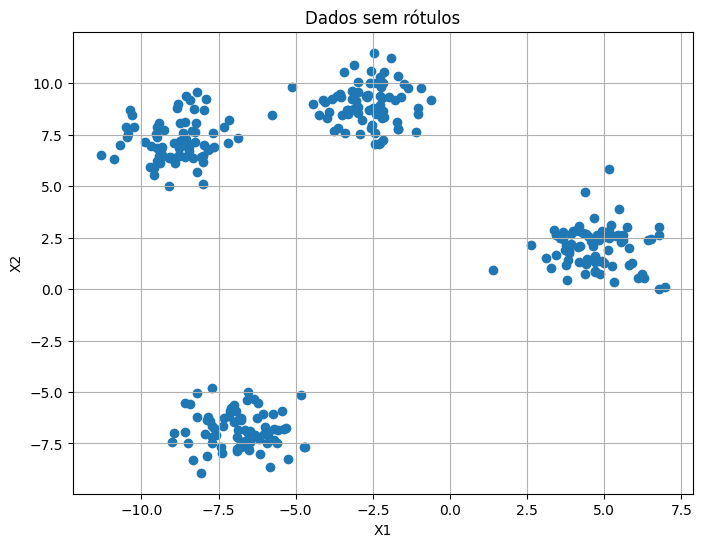

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Dados sem rótulos")
plt.grid(True)
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init="auto",
    random_state=0
)

rotulos = kmeans.fit_predict(X)

print("Rótulos atribuídos pelo K-Means:")
print(rotulos[:20])

print("\nCentróides encontrados:")
print(kmeans.cluster_centers_)

print("\nInércia:")
print(kmeans.inertia_)

(300,)
Rótulos atribuídos pelo K-Means:
[1 1 3 2 1 2 0 2 3 0 3 0 3 3 1 3 1 0 3 3]

Centróides encontrados:
[[ 4.7182049   2.04179676]
 [-8.87357218  7.17458342]
 [-6.83235205 -6.83045748]
 [-2.70981136  8.97143336]]

Inércia:
564.9141808210254


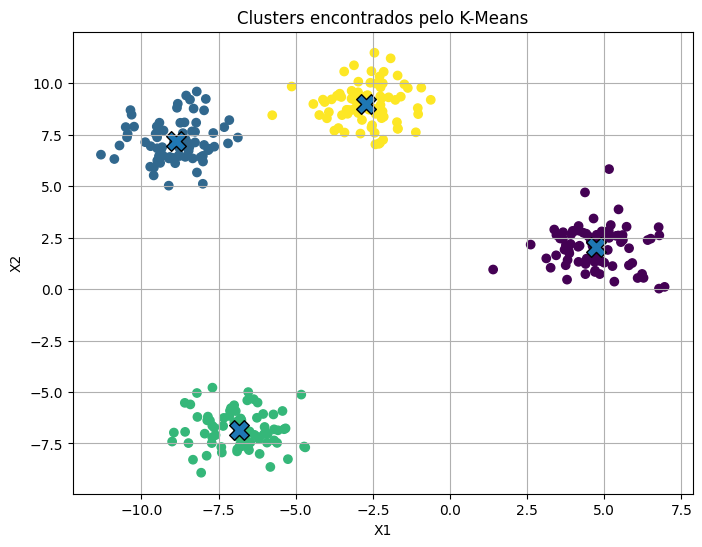

In [ ]:
centroides = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=rotulos)
plt.scatter(
    centroides[:, 0],
    centroides[:, 1],
    marker="X",
    s=200,
    edgecolors="black"
)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Clusters encontrados pelo K-Means")
plt.grid(True)
plt.show()

## Importância de Padronizar/Normalizar os Dados para o uso do K-Means

O K-Means utiliza distância Euclidiana. Portanto, atributos com escalas maiores podem dominar o cálculo da distância.

Por isso, é comum usar `StandardScaler` antes do K-Means.

## Pipeline com StandardScaler e K-Means

Uma prática recomendada é criar um pipeline com:

$$
\text{padronização} \rightarrow \text{K-Means}
$$

Assim, fica garantida que a transformação seja aplicada de forma organizada e reproduzível.

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(
        n_clusters=4,
        init="k-means++",
        n_init="auto",
        random_state=42
    ))
])

rotulos_pipeline = pipeline.fit_predict(X)

print("Rótulos atribuídos pelo pipeline:")
print(rotulos_pipeline[:20])

Rótulos atribuídos pelo pipeline:
[3 3 0 1 3 1 2 1 0 2 0 2 0 0 3 0 3 2 0 0]


# Métricas para Escolher o melhor valor de $k$

Uma das maiores dificuldades do K-Means é escolher o número de clusters.

Duas técnicas comuns são:

1. Método do cotovelo;
2. Índice de silhueta.

## Método do Cotovelo

O método do cotovelo avalia a **inércia** para diferentes valores de $K$.

A inércia sempre diminui quando o valor de $K$ é aumentado. A ideia é que quanto maior o número de clusters a distância média dos pontos aos centróides é reduzida.

O objetivo é procurar um ponto em que a redução da inércia começa a ficar pequena.

Esse ponto lembra visualmente um “cotovelo”.

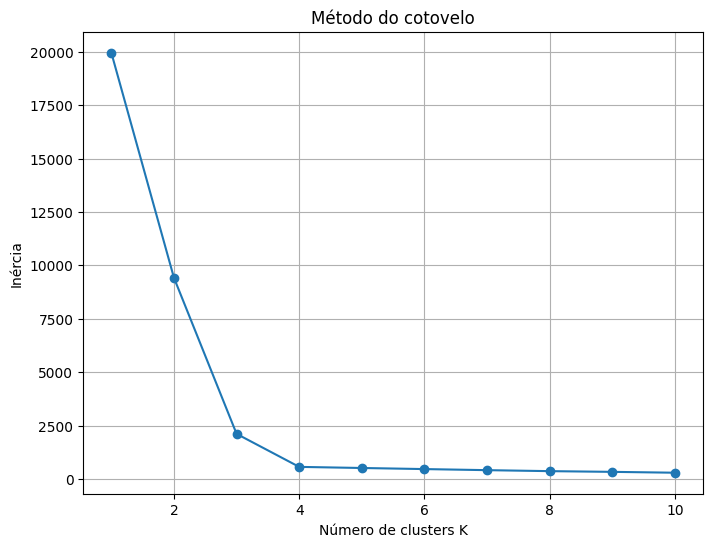

,K,Inércia
0,1,19953.769148
1,2,9416.214004
2,3,2110.412522
3,4,564.914181
4,5,513.032904
5,6,462.096001
6,7,411.348932
7,8,365.355599
8,9,332.036457
9,10,291.560862


In [ ]:
valores_k = range(1, 11)
inercias = []

for k in valores_k:
    modelo = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init="auto",
        random_state=42
    )
    modelo.fit(X)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(list(valores_k), inercias, marker="o")
plt.xlabel("Número de clusters K")
plt.ylabel("Inércia")
plt.title("Método do cotovelo")
plt.grid(True)
plt.show()

pd.DataFrame({
    "K": list(valores_k),
    "Inércia": inercias
})

## Índice de Silhueta

O índice de silhueta mede o quanto os pontos estão bem posicionados dentro de seus clusters.

Para uma amostra $i$, o coeficiente de silhueta é:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

onde:

- $(a(i))$: distância média do ponto para os outros pontos do mesmo cluster;
- $(b(i))$: distância média do ponto para o cluster vizinho mais próximo.

Interpretação:

| Valor | Interpretação |
|---|---|
| Próximo de 1 | Ponto bem agrupado |
| Próximo de 0 | Ponto próximo da fronteira entre clusters |
| Negativo | Possivelmente mal agrupado |

Observação: a silhueta só é definida para $(K \geq 2)$.

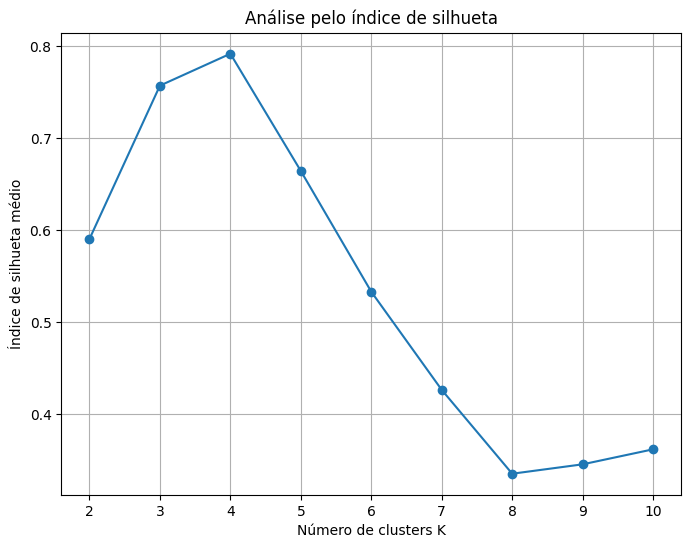

,K,Silhueta média
0,2,0.590218
1,3,0.756911
2,4,0.791583
3,5,0.664187
4,6,0.532952
5,7,0.426312
6,8,0.335211
7,9,0.345426
8,10,0.361733


In [ ]:
valores_k = range(2, 11)
silhuetas = []

for k in valores_k:
    modelo = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init="auto",
        random_state=42
    )
    rotulos_k = modelo.fit_predict(X)
    score = silhouette_score(X, rotulos_k)
    silhuetas.append(score)

plt.figure(figsize=(8, 6))
plt.plot(list(valores_k), silhuetas, marker="o")
plt.xlabel("Número de clusters K")
plt.ylabel("Índice de silhueta médio")
plt.title("Análise pelo índice de silhueta")
plt.grid(True)
plt.show()

pd.DataFrame({
    "K": list(valores_k),
    "Silhueta média": silhuetas
})

## Método do Cotovelo versus Método da Silhueta

| Critério | Ideia principal | Observação |
|---|---|---|
| Cotovelo | Busca uma queda acentuada da inércia | Pode ser subjetivo |
| Silhueta | Mede separação e coesão dos clusters | Não vale para \(K=1\) |

Na prática, é comum usar mais de uma técnica e também considerar o conhecimento do problema.

## Limitações do Algoritmo K-Means

O K-Means é simples e eficiente, mas possui limitações importantes.

| Limitação | Explicação |
|---|---|
| Precisa definir \(K\) | O número de clusters deve ser escolhido antes |
| Sensível à escala | Atributos em escalas diferentes afetam as distâncias |
| Sensível a outliers | Pontos extremos podem deslocar centróides |
| Assume clusters aproximadamente esféricos | Pode falhar em formas complexas |
| Pode cair em mínimos locais | Inicialização dos centróides influencia o resultado |
| Usa distância Euclidiana | Pode não representar bem todos os tipos de dados |

Por isso, o K-Means não é sempre o melhor algoritmo para todos os problemas.

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

# Créditos

* Imagens geradas pelo chatgpt.